In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvbWF4L2F1bGEtcXVhbnR1bS9jb250ZW50LzExLXFmdC1xcGU='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/importlib/_bootstrap.py": 1787687117.0310943, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/importlib/_bootstrap_external.py": 1787687117.0310943, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/codecs.py": 1787687116.7980936, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/aliases.py": 1787687116.852094, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/__init__.py": 1787687116.8510938, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/utf_8.py": 1787687116.888094, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/abc.py": 1787687116.7790935, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/io.py": 1787687117.0350945, "/home/max/.local/share/uv/python/cpython-3.10-linu

In [2]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt

In [3]:
# 1. PREPARAÇÃO: Codificar o número 6 (Binário 110)
# Em Qiskit (Little Endian): q0 é o menos significativo.
# 6 = 0 * (2^0) + 1 * (2^1) + 1 * (2^2) -> q0=0, q1=1, q2=1
num_qubits = 3
qc = QuantumCircuit(num_qubits)

# Codificando o '6' (Portas X onde o bit é 1)
# qc.x(0) # q0 = 0 (não fazemos nada)
qc.x(1) # q1 = 1
qc.x(2) # q2 = 1

# Vamos salvar o estado visual ANTES da QFT
estado_antes = Statevector(qc)
print("--- Estado Antes (Binário 110) ---")
# Vai mostrar setas para baixo (1) e para cima (0)

--- Estado Antes (Binário 110) ---


/tmp/ipykernel_657570/638381934.py:3: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_qft = QFT(num_qubits, do_swaps=False).to_gate()


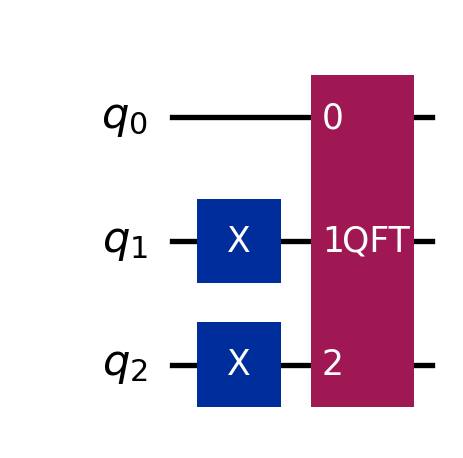

In [4]:
# 2. A MÁGICA: Aplicar a QFT
# A biblioteca cria o circuito complexo de Hadamards e Rotações para nós
qc_qft = QFT(num_qubits, do_swaps=False).to_gate()
qc.append(qc_qft, range(num_qubits))

# Vamos salvar o estado visual DEPOIS da QFT
estado_depois = Statevector(qc)

# Desenha o circuito completo
qc.draw('mpl') 


--- Gerando Esferas de Bloch... ---


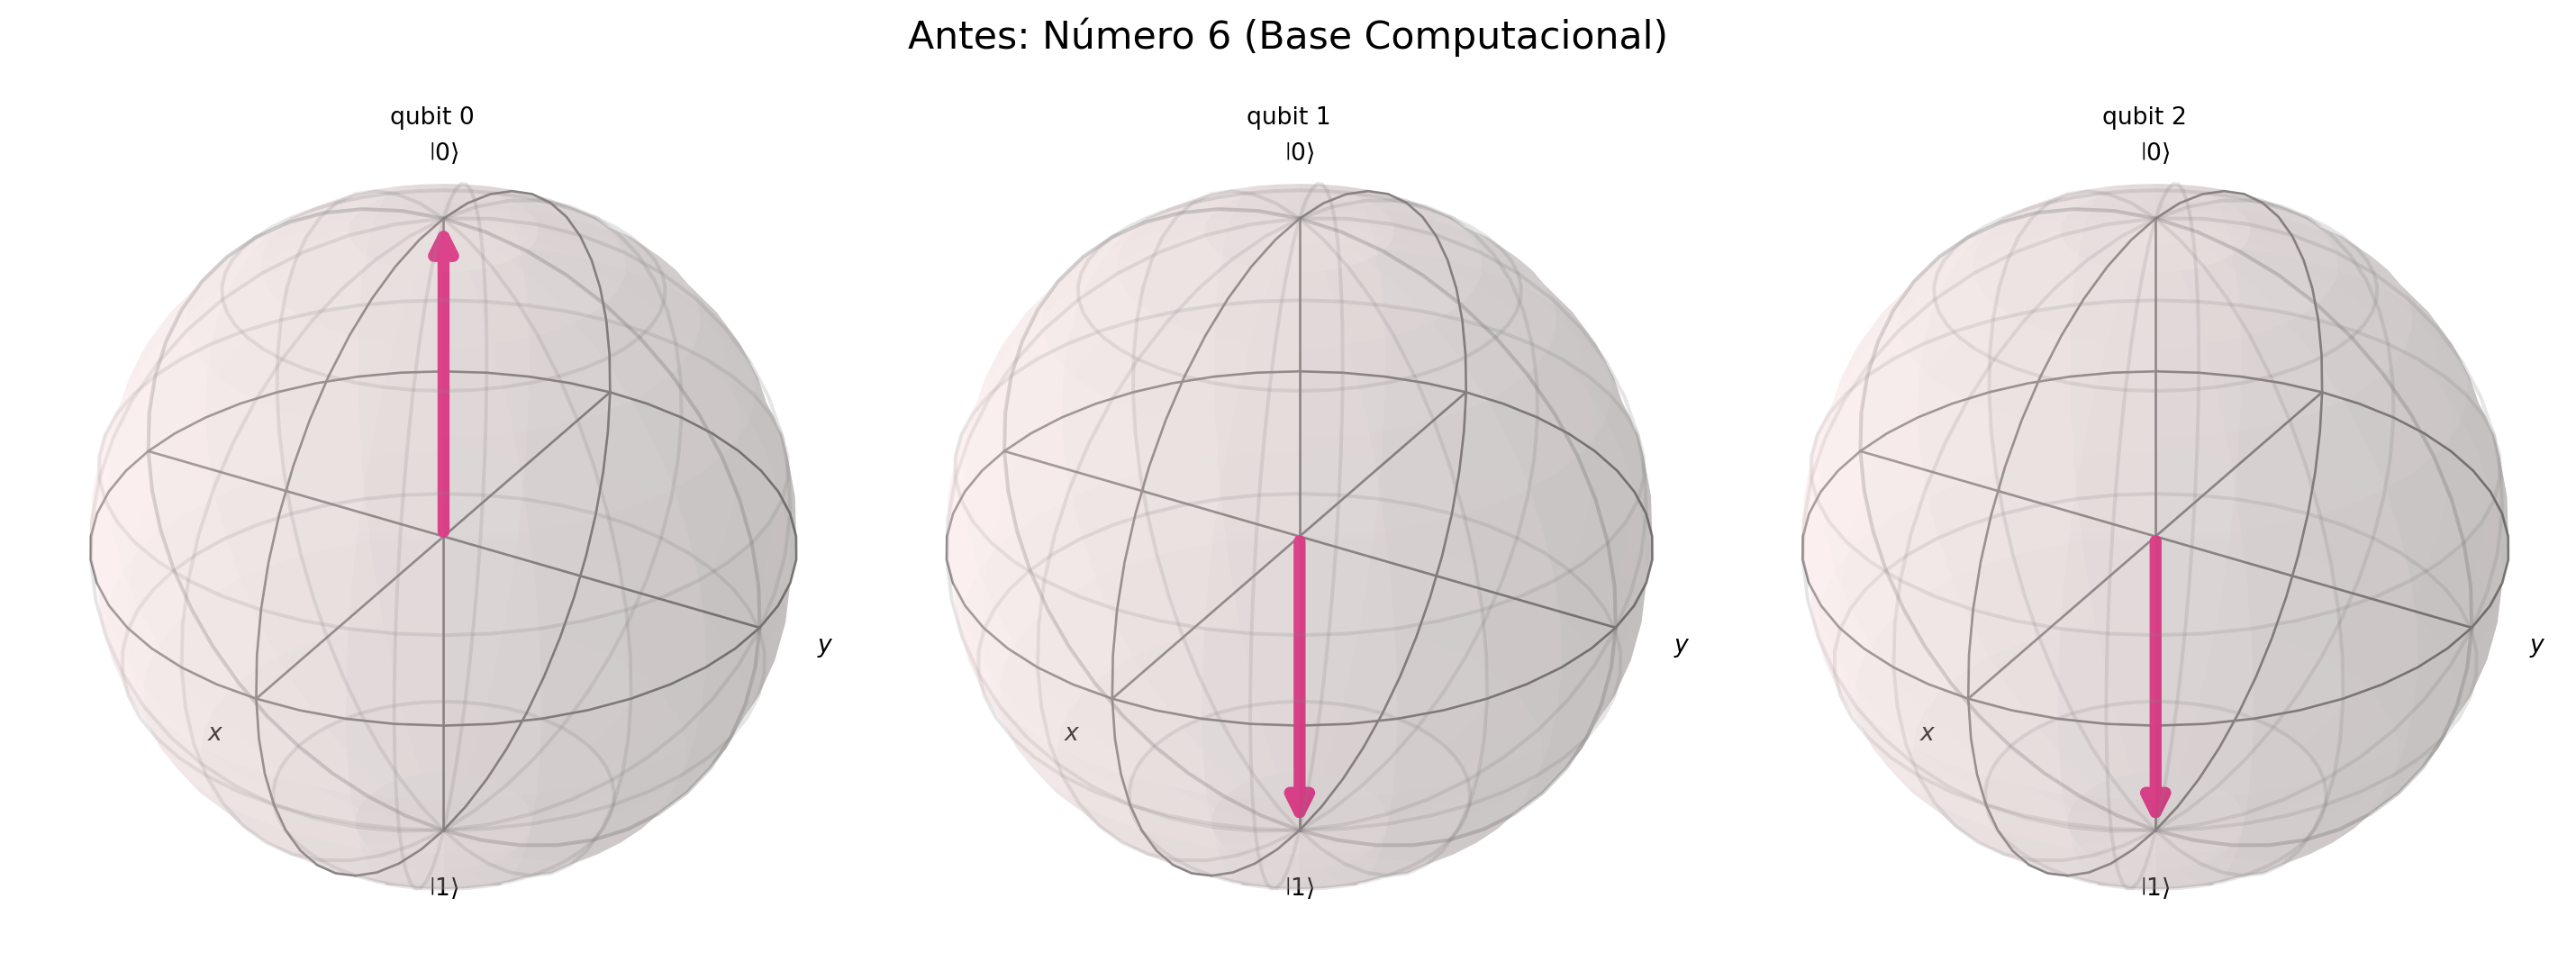

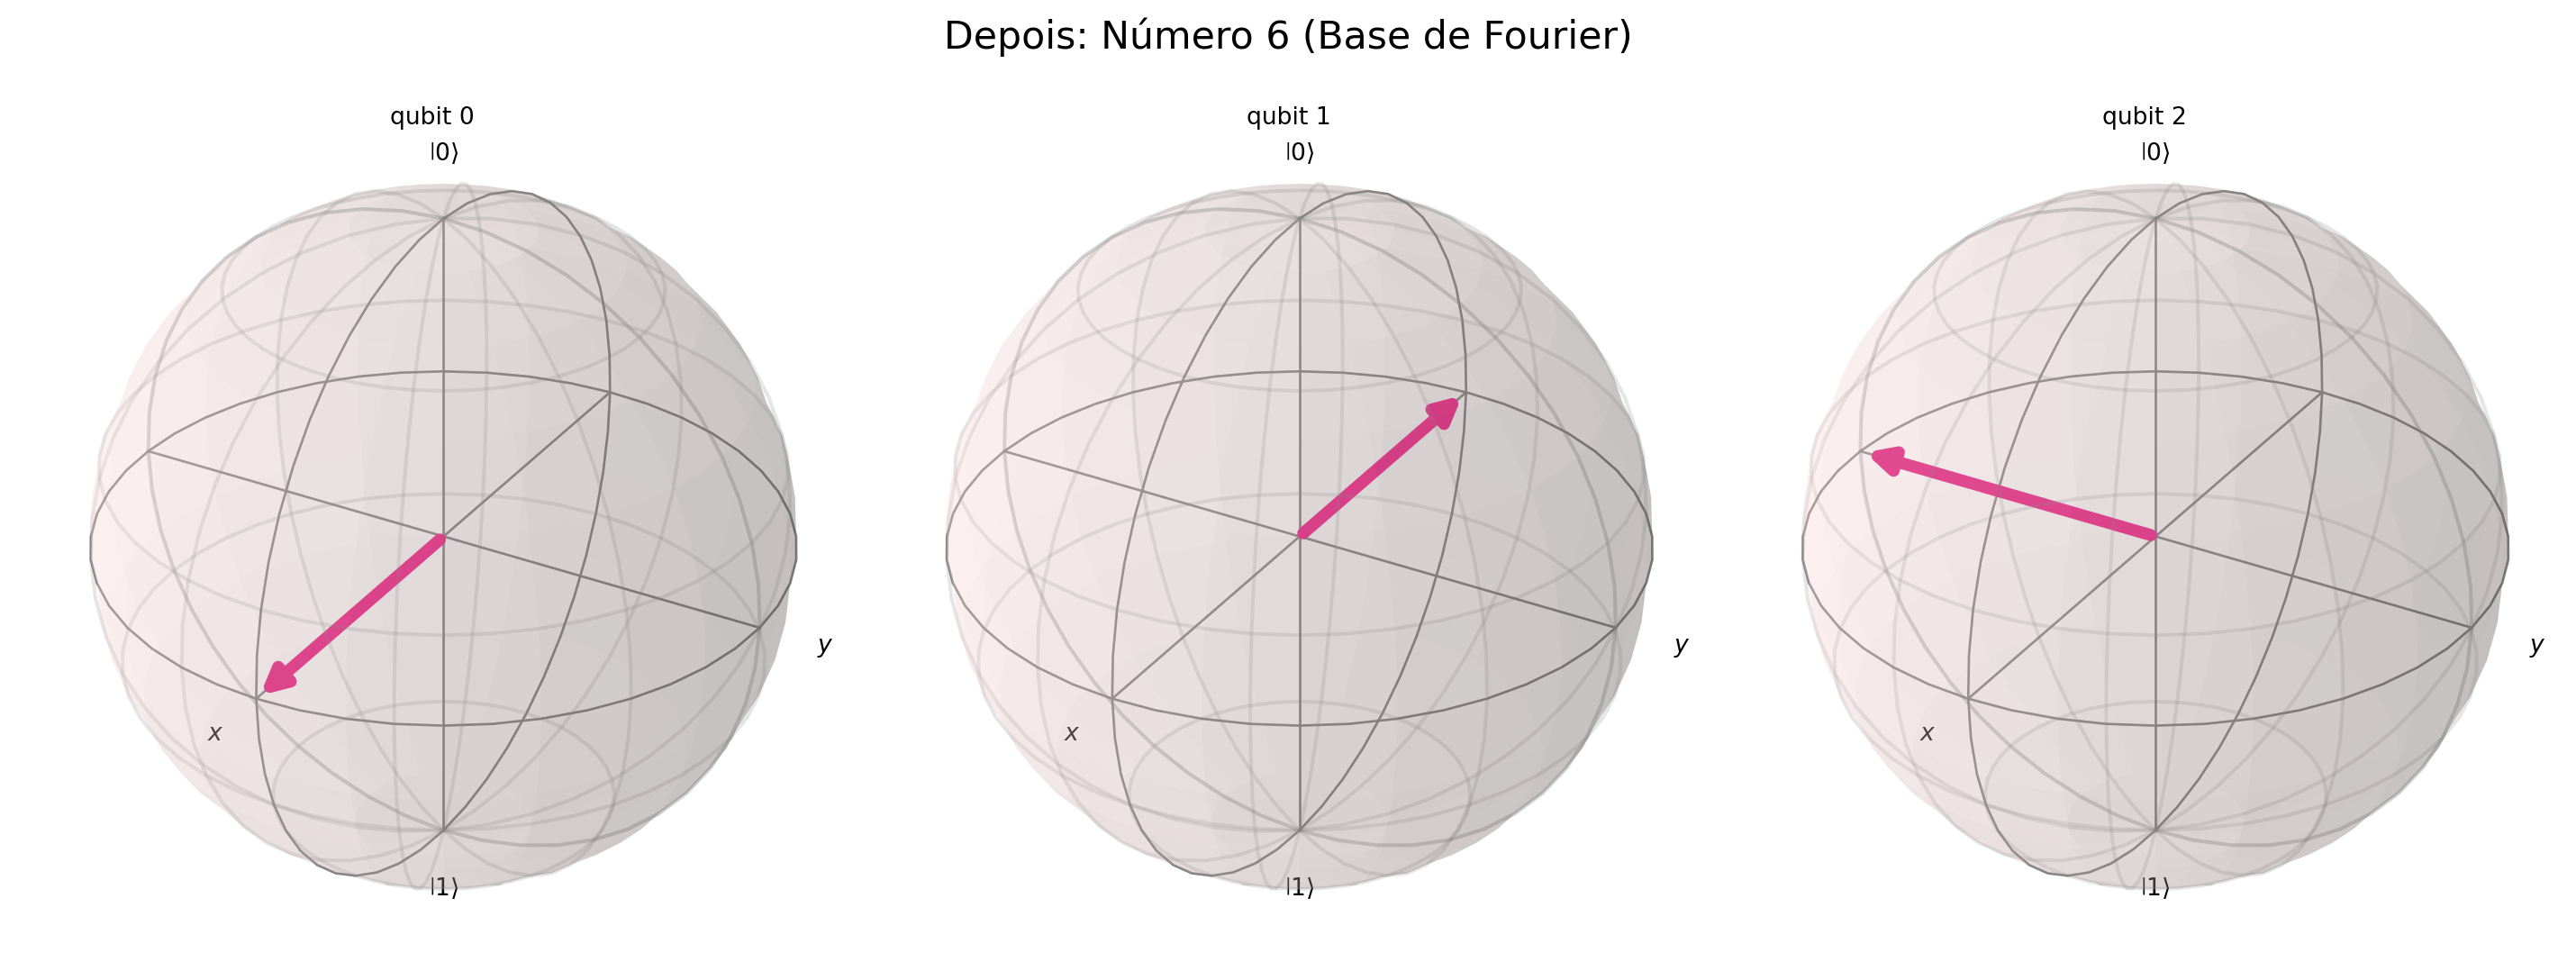

In [5]:
from IPython.display import display

# 3. VISUALIZAÇÃO
print("\n--- Gerando Esferas de Bloch... ---")

# Plot 1: Binário Puro
fig1 = plot_bloch_multivector(estado_antes, title="Antes: Número 6 (Base Computacional)")
display(fig1)

# Plot 2: Fourier
fig2 = plot_bloch_multivector(estado_depois, title="Depois: Número 6 (Base de Fourier)")
display(fig2)

In [6]:
# Visualizar o vetor de estados com melhor formatação
print("\n=== ESTADO ANTES DA QFT (Base Computacional) ===")
print(f"Representação: |110⟩ (número 6 em binário)")
display(estado_antes.draw('latex'))
print(f"\nAmplitudes:")
for i, amp in enumerate(estado_antes.data):
    if abs(amp) > 1e-10:  # Mostrar apenas amplitudes não-zero
        print(f"  |{i:03b}⟩: {amp.real:+.8f} {amp.imag:+.8f}j  (|amp| = {abs(amp):.8f})")


=== ESTADO ANTES DA QFT (Base Computacional) ===
Representação: |110⟩ (número 6 em binário)


<IPython.core.display.Latex object>


Amplitudes:
  |110⟩: +1.00000000 +0.00000000j  (|amp| = 1.00000000)


In [7]:
print("\n" + "="*60)
print("\n=== ESTADO DEPOIS DA QFT (Base de Fourier) ===")
print(f"Informação codificada nas fases (rotações)")
display(estado_depois.draw('latex'))
print(f"\nAmplitudes α, β, ... (note os valores complexos):")
for i, amp in enumerate(estado_depois.data):
    print(f"Estado |{i:03b}⟩: {amp.real:+.8f} {amp.imag:+.8f}j")

# Mostrar as fases de cada amplitude
print("\n--- Fases (ângulos) de cada amplitude ---")
fases = np.angle(estado_depois.data, deg=True)
for i, fase in enumerate(fases):
    print(f"Estado |{i:03b}⟩: Fase = {fase:7.2f}°")



=== ESTADO DEPOIS DA QFT (Base de Fourier) ===
Informação codificada nas fases (rotações)


<IPython.core.display.Latex object>


Amplitudes α, β, ... (note os valores complexos):
Estado |000⟩: +0.35355339 +0.00000000j
Estado |001⟩: +0.35355339 +0.00000000j
Estado |010⟩: -0.35355339 +0.00000000j
Estado |011⟩: -0.35355339 +0.00000000j
Estado |100⟩: -0.00000000 -0.35355339j
Estado |101⟩: -0.00000000 -0.35355339j
Estado |110⟩: +0.00000000 +0.35355339j
Estado |111⟩: +0.00000000 +0.35355339j

--- Fases (ângulos) de cada amplitude ---
Estado |000⟩: Fase =    0.00°
Estado |001⟩: Fase =    0.00°
Estado |010⟩: Fase =  180.00°
Estado |011⟩: Fase =  180.00°
Estado |100⟩: Fase =  -90.00°
Estado |101⟩: Fase =  -90.00°
Estado |110⟩: Fase =   90.00°
Estado |111⟩: Fase =   90.00°


In [8]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT, PhaseGate
from qiskit.visualization import plot_histogram

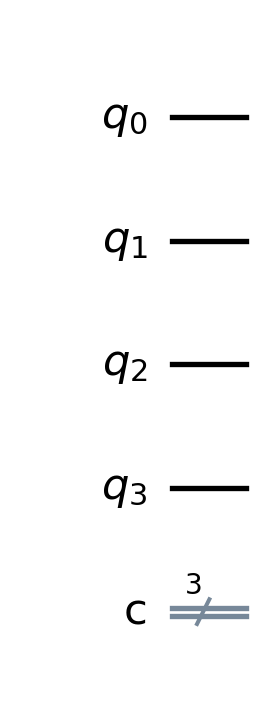

In [9]:
# --- 1. CONFIGURAÇÃO ---
# Precisamos de qubits para "contar" a fase (precisão) e 1 (q3) para sofrer a ação
num_qubits_contagem = 3 
num_qubits_total = num_qubits_contagem + 1 # +1 para o alvo

qc = QuantumCircuit(num_qubits_total, num_qubits_contagem)
qc.draw('mpl')

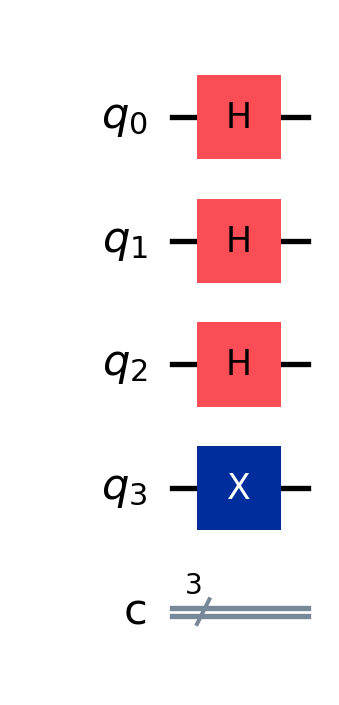

In [10]:
# --- 2. PREPARAÇÃO ---
# Colocar os qubits de contagem em superposição (para receberem o kickback)
for qubit in range(num_qubits_contagem):
    qc.h(qubit)

# Colocar o qubit alvo (o último) no estado |1>
# (O Kickback só funciona se o alvo for |1>, lembre-se do eigenstate)
qc.x(num_qubits_contagem)
qc.draw('mpl')

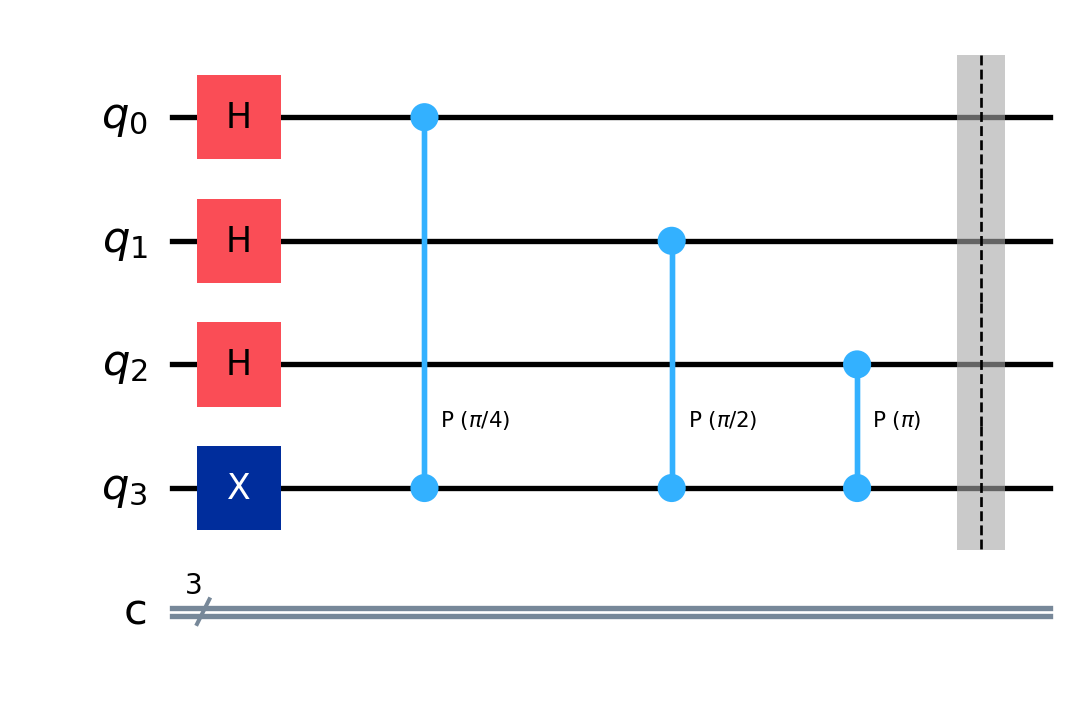

In [11]:
# --- 3. APLICAÇÃO DA PORTA "MISTERIOSA" (U) ---
# Vamos definir nossa fase secreta: 1/8 de volta
# Fase = 2 * pi * (1/8)
fase_secreta = 2 * np.pi * (1/8)

# Aplicamos a porta controlada repetidamente (Kickback em cascata)
# Qubit 0 aplica U^1
# Qubit 1 aplica U^2
# Qubit 2 aplica U^4
repeticoes = 1
for counting_qubit in range(num_qubits_contagem):
    # PhaseGate Controlada (CP)
    # qc.cp(angulo, controle, alvo). Esta porta foi vista anteriormente.
    qc.cp(fase_secreta * repeticoes, counting_qubit, num_qubits_contagem)
    repeticoes = repeticoes * 2

qc.barrier()
qc.draw('mpl')

/tmp/ipykernel_657570/3409750826.py:4: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_iqft = QFT(num_qubits_contagem, inverse=True).to_gate()


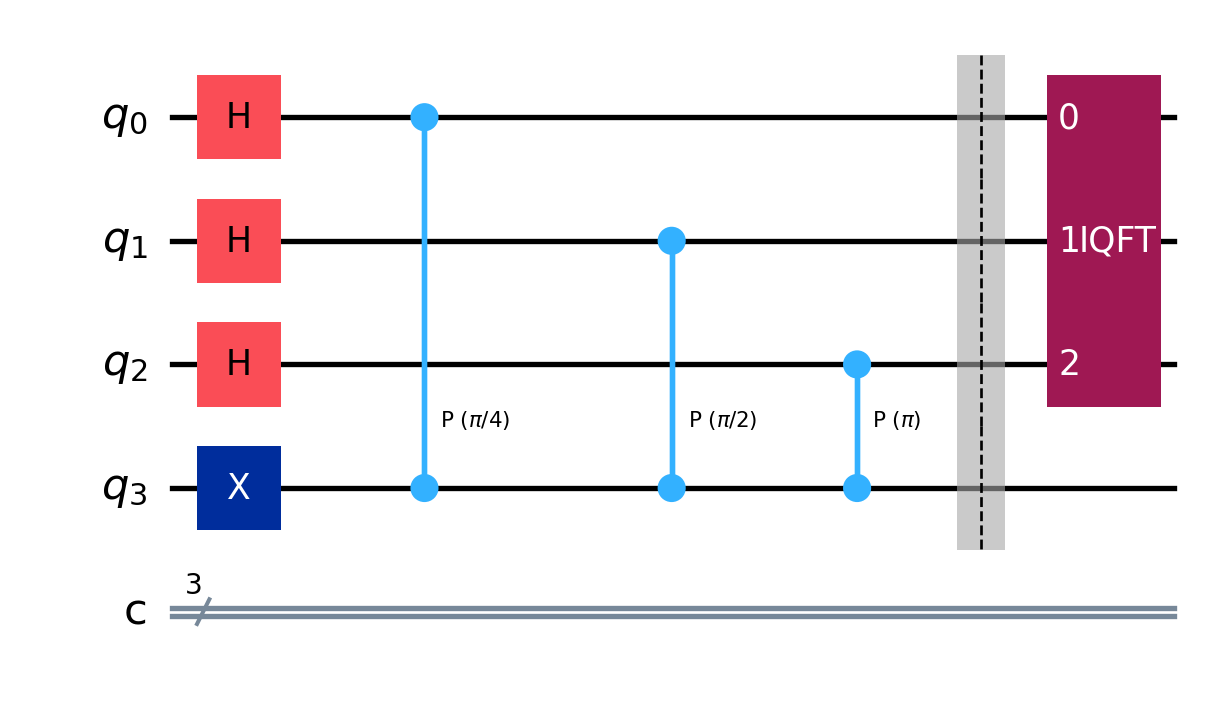

In [12]:
# --- 4. O DECODIFICADOR (QFT INVERSA) ---
# Até aqui, a informação do ângulo está escondida na fase dos qubits de contagem.
# A QFT Inversa traduz isso para bits legíveis (0 ou 1).
qc_iqft = QFT(num_qubits_contagem, inverse=True).to_gate()
qc.append(qc_iqft, range(num_qubits_contagem))
qc.draw('mpl')

In [13]:
# --- 5. MEDIÇÃO ---
qc.measure(range(num_qubits_contagem), range(num_qubits_contagem))

In [14]:
# --- EXECUÇÃO ---
simulador = AerSimulator()
job = simulador.run(transpile(qc, simulador), shots=1024)
contagens = job.result().get_counts()

In [15]:
# --- INTERPRETAÇÃO ---
# A saída será um binário, ex: '001'.
# Isso deve ser lido como fração binária: 0.001
# 0*(1/2) + 0*(1/4) + 1*(1/8) = 1/8.

print("\n--- Resultado da QPE ---")
print(f"Contagens (Binário): {contagens}")

# Converter o binário mais provável para decimal
leitura_binaria = list(contagens.keys())[0]
decimal = int(leitura_binaria, 2)
fase_estimada = decimal / (2**num_qubits_contagem)

print(f"Binário lido: {leitura_binaria} (Decimal: {decimal})")
print(f"Fase Estimada: {fase_estimada}")
print(f"Fase Real Esperada: {1/8}")


--- Resultado da QPE ---
Contagens (Binário): {'001': 1024}
Binário lido: 001 (Decimal: 1)
Fase Estimada: 0.125
Fase Real Esperada: 0.125
